# Data Wrangling — Synthetic Vietnamese Students’ Feedback

Nguồn: [Kaggle — toreleon/synthetic-vietnamese-students-feedback-corpus](https://www.kaggle.com/datasets/toreleon/synthetic-vietnamese-students-feedback-corpus)

1. `student_feedback_data/synthetic_train.csv` (train)  
2. `student_feedback_data/synthetic_val.csv` (validation)  

Dữ liệu **văn bản**: missing → làm sạch câu; chuẩn hoá đơn vị → điểm sentiment; normalize → độ dài câu; binning → ngắn/trung/dài; dummy → `topic`.

Mỗi bước có **1 dòng mẫu**. Dòng `# TODO` em làm tương tự (đổi tên cột / file).

## Download data and explore

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? câu rỗng / chỉ khoảng trắng?

| Cột | Kiểu | Ý nghĩa |
|---|---|---|
| `sentence` | object | Câu phản hồi (VN hoặc EN). Không trùng trong từng file. |
| `sentiment` | object | Nhãn cảm xúc: `negative` / `neutral` / `positive` (gần cân bằng). |
| `topic` | object | Chủ đề: `lecturer`, `curriculum`, `facility`, `others`. |

**Ghi chú:** Không có `NaN` sẵn. Một số câu là tiếng Anh (không dấu). Cần tạo biến số (độ dài câu) để normalize / binning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

path_train = "student_feedback_data/synthetic_train.csv"
path_val = "student_feedback_data/synthetic_val.csv"

df_train = pd.read_csv(path_train) 
# TODO: đọc path_val vào df_val (giống dòng trên)
df_val = pd.read_csv(path_val)

print("Train:", df_train.shape)  # mẫu: in số dòng, số cột
# TODO: in shape của df_val
print("Val",df_val.shape)

print(df_train.dtypes)  # mẫu: xem kiểu cột
df_train.head()  # mẫu: 5 dòng đầu
# TODO: xem 5 dòng đầu df_val
df_val.head()

Train: (8144, 3)
Val (2036, 3)
sentence     object
sentiment    object
topic        object
dtype: object


,sentence,sentiment,topic
0,Chất lượng vật chất kém.,negative,facility
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,facility
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,facility
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,curriculum
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,others


---
# Bộ 1 — Train

## 1. Xử lý giá trị thiếu (Missing Values)

Câu rỗng / chỉ khoảng trắng → `NaN`. `sentiment` / `topic` (phân loại) → **mode**. `sentence` là nội dung chính → **drop** dòng thiếu rồi `reset_index`.

In [3]:
df = df_train.copy()  # làm việc trên bản sao

# TODO: strip và thay các giá trị thiếu trên 3 cột
replace_dict = {"nan": np.nan, "": np.nan, "None": np.nan}

for col in ["sentence", "sentiment", "topic"]:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(replace_dict)

# TODO: Kiểm tra missing trước khi xử lý
print(df.isnull().sum())

# TODO: Điền missing bằng mode cho sentiment và topic
df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode()[0])
df["topic"] = df["topic"].fillna(df["topic"].mode()[0])

# TODO: Xóa các dòng thiếu sentence vì đây là nội dung chính
df = df.dropna(subset=["sentence"]).reset_index(drop=True)

# TODO: Kiểm tra lại missing và số dòng sau khi xử lý
print(df.isnull().sum())
print("len(df):", len(df))


sentence     0
sentiment    0
topic        0
dtype: int64
sentence     0
sentiment    0
topic        0
dtype: int64
len(df): 8144


## 2. Sửa định dạng dữ liệu (Correct Data Format)

Ép `sentiment`, `topic` về kiểu `category`. Thêm độ dài câu (`n_chars`, `n_words`) dạng số.

In [4]:
print(df.dtypes)  

sentence     object
sentiment    object
topic        object
dtype: object


In [8]:


df["sentiment"] = df["sentiment"].astype("category")  # mẫu: chữ → category
# TODO: ép topic về category (giống dòng trên)
df["topic"] = df["topic"].astype("category")

df["n_chars"] = df["sentence"].str.len().astype(int)  # mẫu: số ký tự
# TODO: n_words = sentence.str.split().str.len() rồi astype(int)
df["n_words"] = df["sentence"].str.len().astype(int)

df[["sentence", "n_chars"]].head()  # mẫu
# TODO: head thêm cột n_words; in lại dtypes
print(df[["sentence","n_chars","n_words" ]].head())
print(df.dtypes)

                                            sentence  n_chars  n_words
0  Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...       86       86
1  The university's musical and artistic faciliti...       63       63
2  Phương pháp giảng dạy phù hợp với các đối tượn...       68       68
3  Chương trình học giúp tôi trở thành một chuyên...       75       75
4  Tôi nghĩ rằng chương trình đào tạo có thể có t...      142      142
sentence                object
sentiment             category
topic                 category
n_chars                  int32
n_words                  int32
sentiment_score          int32
n_chars_normalized     float64
n_words_normalized     float64
dtype: object


## 3. Chuẩn hoá dữ liệu (Data Standardization)

Đưa nhãn cảm xúc về **cùng thang số**: `negative → -1`, `neutral → 0`, `positive → 1`.

In [6]:
sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}  # mẫu: từ điển nhãn → số

# TODO: cột sentiment_score = df["sentiment"].map(sentiment_map).astype(int)
df["sentiment_score"] = df["sentiment"].map(sentiment_map).astype(int)

df[["sentiment","sentiment_score"]].drop_duplicates()  # mẫu: xem các nhãn
# TODO: head / drop_duplicates hai cột sentiment và sentiment_score



,sentiment,sentiment_score
0,negative,-1
1,neutral,0
3,positive,1


## 4. Chuẩn hoá phạm vi giá trị (Data Normalization)

`n_chars` lớn hơn `n_words` → `x / x.max()` về 0–1.

In [9]:
# TODO: Chuẩn hóa n_chars và n_words về khoảng 0–1
df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max()
df["n_words_normalized"] = df["n_words"] / df["n_words"].max()

# TODO: Kiểm tra kết quả chuẩn hóa
df[[
    "n_chars", "n_chars_normalized",
    "n_words", "n_words_normalized"
]].head()


,n_chars,n_chars_normalized,n_words,n_words_normalized
0,86,0.452632,86,0.452632
1,63,0.331579,63,0.331579
2,68,0.357895,68,0.357895
3,75,0.394737,75,0.394737
4,142,0.747368,142,0.747368


## 5. Phân nhóm (Binning)

Chia độ dài câu (số từ) thành Short / Medium / Long bằng `pd.cut()`.

length_binned
Short     4694
Medium    3345
Long       105
Name: count, dtype: int64


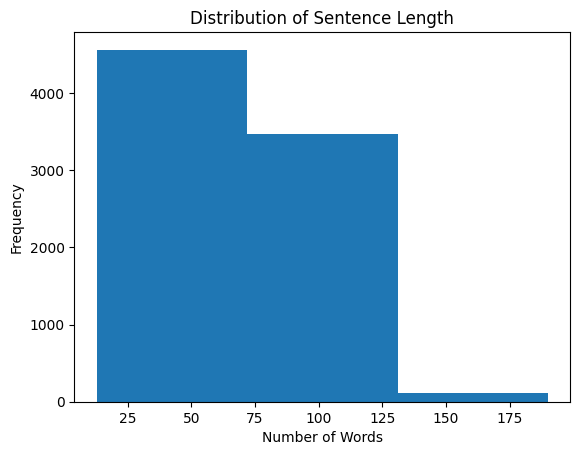

,n_words,length_binned
0,86,Medium
1,63,Short
2,68,Short
3,75,Medium
4,142,Long


In [10]:
# TODO: Chia n_words thành 3 khoảng có độ rộng bằng nhau
bins = np.linspace(df["n_words"].min(), df["n_words"].max(), 4)

df["length_binned"] = pd.cut(
    df["n_words"],
    bins=bins,
    labels=["Short", "Medium", "Long"],
    include_lowest=True
)

# TODO: Đếm số câu trong mỗi nhóm
length_counts = df["length_binned"].value_counts().sort_index()
print(length_counts)

# TODO: Vẽ histogram phân bố độ dài câu
plt.hist(df["n_words"], bins=3)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Length")
plt.show()

# TODO: Kiểm tra kết quả phân nhóm
df[["n_words", "length_binned"]].head()


## 6. Biến chỉ thị / Biến giả (Dummy Variable)

`topic` (chữ) → mỗi chủ đề một cột 0/1. Giữ `sentiment` làm nhãn dự đoán.

In [11]:
dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int)  # mẫu: cột 0/1

# TODO: gộp dummy vào df — pd.concat([df, dummy_topic], axis=1)
pd.concat([df, dummy_topic], axis=1)
# TODO: xoá cột gốc topic — df.drop(columns=["topic"])  (giữ sentiment)
df.drop(columns=["topic"])
df.head()  # mẫu

,sentence,sentiment,topic,n_chars,n_words,sentiment_score,n_chars_normalized,n_words_normalized,length_binned
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,facility,86,86,-1,0.452632,0.452632,Medium
1,The university's musical and artistic faciliti...,neutral,facility,63,63,0,0.331579,0.331579,Short
2,Phương pháp giảng dạy phù hợp với các đối tượn...,neutral,curriculum,68,68,0,0.357895,0.357895,Short
3,Chương trình học giúp tôi trở thành một chuyên...,positive,curriculum,75,75,1,0.394737,0.394737,Medium
4,Tôi nghĩ rằng chương trình đào tạo có thể có t...,neutral,curriculum,142,142,0,0.747368,0.747368,Long


## Check and save

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ cố ý để thiếu)
* `n_chars`, `n_words` là số
* có cột mới: `sentiment_score`, `*_normalized`, `length_binned`, `topic_*`

`index=False` để file không thêm cột index 0,1,2,…


In [12]:
df.to_csv("student_feedback_train_clean.csv", index=False)  # mẫu: lưu train
print(df.shape)


(8144, 9)


In [13]:
# TODO: (tuỳ chọn) gán df_train_clean = df
df_train_clean = df

---
---
# Bộ 2 — Validation

Làm **giống bộ train**, đổi `df_train` → `df_val`. Copy mẫu ở trên, sửa tên biến / title. Kết thúc bằng **Check and save** (`to_csv`, `index=False`).


sentence     0
sentiment    0
topic        0
dtype: int64
length_binned
Short     1385
Medium     634
Long        17
Name: count, dtype: int64


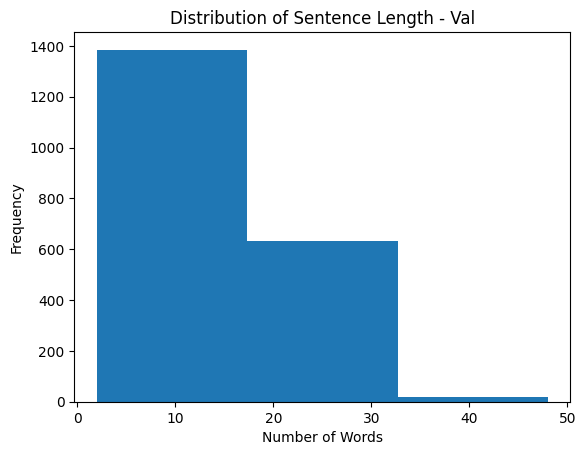

(2036, 12)


,sentence,sentiment,n_chars,n_words,sentiment_score,n_chars_normalized,n_words_normalized,length_binned,topic_curriculum,topic_facility,topic_lecturer,topic_others
0,Chất lượng vật chất kém.,negative,24,5,-1,0.112150,0.104167,Short,0,1,0,0
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,68,15,-1,0.317757,0.312500,Short,0,1,0,0
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,120,25,-1,0.560748,0.520833,Medium,0,1,0,0
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,64,14,0,0.299065,0.291667,Short,1,0,0,0
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,57,12,0,0.266355,0.250000,Short,0,0,0,1


In [14]:
df = df_val.copy()  # bắt đầu từ validation

# TODO: Strip + replace nan/""/"None" cho sentence, sentiment, topic
replace_dict = {"nan": np.nan, "": np.nan, "None": np.nan}

for col in ["sentence", "sentiment", "topic"]:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(replace_dict)

# TODO: Kiểm tra missing trước khi xử lý
print(df.isnull().sum())

# TODO: Điền missing bằng mode cho sentiment và topic
df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode()[0])
df["topic"] = df["topic"].fillna(df["topic"].mode()[0])

# TODO: Xóa dòng thiếu sentence
df = df.dropna(subset=["sentence"]).reset_index(drop=True)


# TODO: Bước 2 — Ép sentiment và topic thành category
df["sentiment"] = df["sentiment"].astype("category")
df["topic"] = df["topic"].astype("category")

# TODO: Tạo số ký tự và số từ trong câu
df["n_chars"] = df["sentence"].str.len().astype(int)
df["n_words"] = df["sentence"].str.split().str.len().astype(int)


# TODO: Bước 3 — Chuyển sentiment thành điểm số
sentiment_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

df["sentiment_score"] = df["sentiment"].map(sentiment_map).astype(int)


# TODO: Bước 4 — Chuẩn hóa n_chars và n_words về 0–1
df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max()
df["n_words_normalized"] = df["n_words"] / df["n_words"].max()


# TODO: Bước 5 — Chia n_words thành 3 nhóm
bins = np.linspace(df["n_words"].min(), df["n_words"].max(), 4)

df["length_binned"] = pd.cut(
    df["n_words"],
    bins=bins,
    labels=["Short", "Medium", "Long"],
    include_lowest=True
)

# TODO: Đếm số câu trong mỗi nhóm
print(df["length_binned"].value_counts())

# TODO: Vẽ histogram
plt.hist(df["n_words"], bins=3)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Length - Val")
plt.show()


# TODO: Bước 6 — One-hot encoding cho topic
dummy_topic = pd.get_dummies(
    df["topic"],
    prefix="topic",
    dtype=int
)

# TODO: Gộp dummy vào df và xóa cột topic gốc
df = pd.concat([df, dummy_topic], axis=1)
df = df.drop(columns=["topic"])


# TODO: Bước 7 — Lưu file validation
df.to_csv("student_feedback_val_clean.csv", index=False)

# TODO: Kiểm tra shape và dữ liệu
print(df.shape)
df.head()
